In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

import utils_reg as utils
from gpflow.kernels import SquaredExponential
from utils_data import load_data

# Set the font to times new roman
plt.rcParams["font.family"] = "Times New Roman"

In [2]:
from matplotlib import ticker


def plot_model(model, ax, cur_x, cur_y, pred_x, model_full = None, seen_x=None, seen_y=None, plot_mean = True, plot_samples = False, color = 'C0'):
    mx, vx = model.predict_f(pred_x)
    Zopt = model.inducing_variable.Z.numpy()
    mu_old, Su_old = model.predict_f(Zopt, full_cov=True)
    if len(Su_old.shape) == 3:
        Su_old= Su_old[0, :, :]
        vx = vx[:, 0]

    ax.plot(cur_x, cur_y, 'x', color = 'C1', mew=1, alpha=0.8, label='Data')
    
    if seen_x is not None:
        ax.plot(seen_x, seen_y, 'kx', mew=1, alpha=0.2, label='Seen data')
    
    if plot_mean:
        ax.plot(pred_x, mx, lw=1.5, label="Mean", color = color)

    if plot_samples:
        f_samples = model.predict_f_samples(pred_x, 10)
        ax.plot(pred_x,f_samples[:, :, 0].numpy().T, color='C0', alpha=0.4, lw=0.5)

    ax.fill_between(
        pred_x[:, 0], mx[:, 0] -  2*np.sqrt(vx), 
        mx[:, 0] +  2*np.sqrt(vx),  alpha=0.3, label="Approx. Post.", color = color)
    
    ax.plot(Zopt, mu_old, 'o', color='k', mew=2, label="Inducing Points")

    if model_full is not None: 
        mx_full, vx_full = model_full.predict_f(pred_x)
        ax.plot(pred_x, mx_full + 2.0 * vx_full ** 0.5, color='k', linestyle='--', linewidth=2.0)
        ax.plot(pred_x, mx_full - 2.0 * vx_full** 0.5, color='k', linestyle='--', linewidth=2.0, label="Full GP")

    ax.set_ylim([-2, 2 ])
    ax.set_xlim([np.min(pred_x), np.max(pred_x)])
    plt.subplots_adjust(hspace = .08)
    ax.yaxis.set_ticks(np.arange(-2, 3, 1))
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%0.1f'))
    ax.xaxis.set_tick_params(labelsize=15)
    ax.yaxis.set_tick_params(labelsize=15)


In [3]:
def get_data_snelson():
    d = load_data("snelson1d.mat")
    X, y = (d.X - 3) / 2, d.Y
    df = pd.DataFrame(np.hstack((X, y)), columns=['x', 'y'])
    df.sort_values(by=['x'], inplace=True)
    X, y = df['x'].values.reshape(-1, 1), df['y'].values.reshape(-1, 1)
    return X, y

In [4]:
X, y = get_data_snelson()
xx = np.linspace(-2, 2, 300)[:, None]

ValueError: Dataset snelson1d.mat unknown...

In [ ]:
from gpflow.models import GPR
full_model = GPR((X, y), kernel=SquaredExponential())
utils.run_optimization(full_model)

2025-06-16 09:51:18.938689: W tensorflow/tsl/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


Terminating selection of inducing points, M =  5
Terminating selection of inducing points, M =  8
Terminating selection of inducing points, M =  12


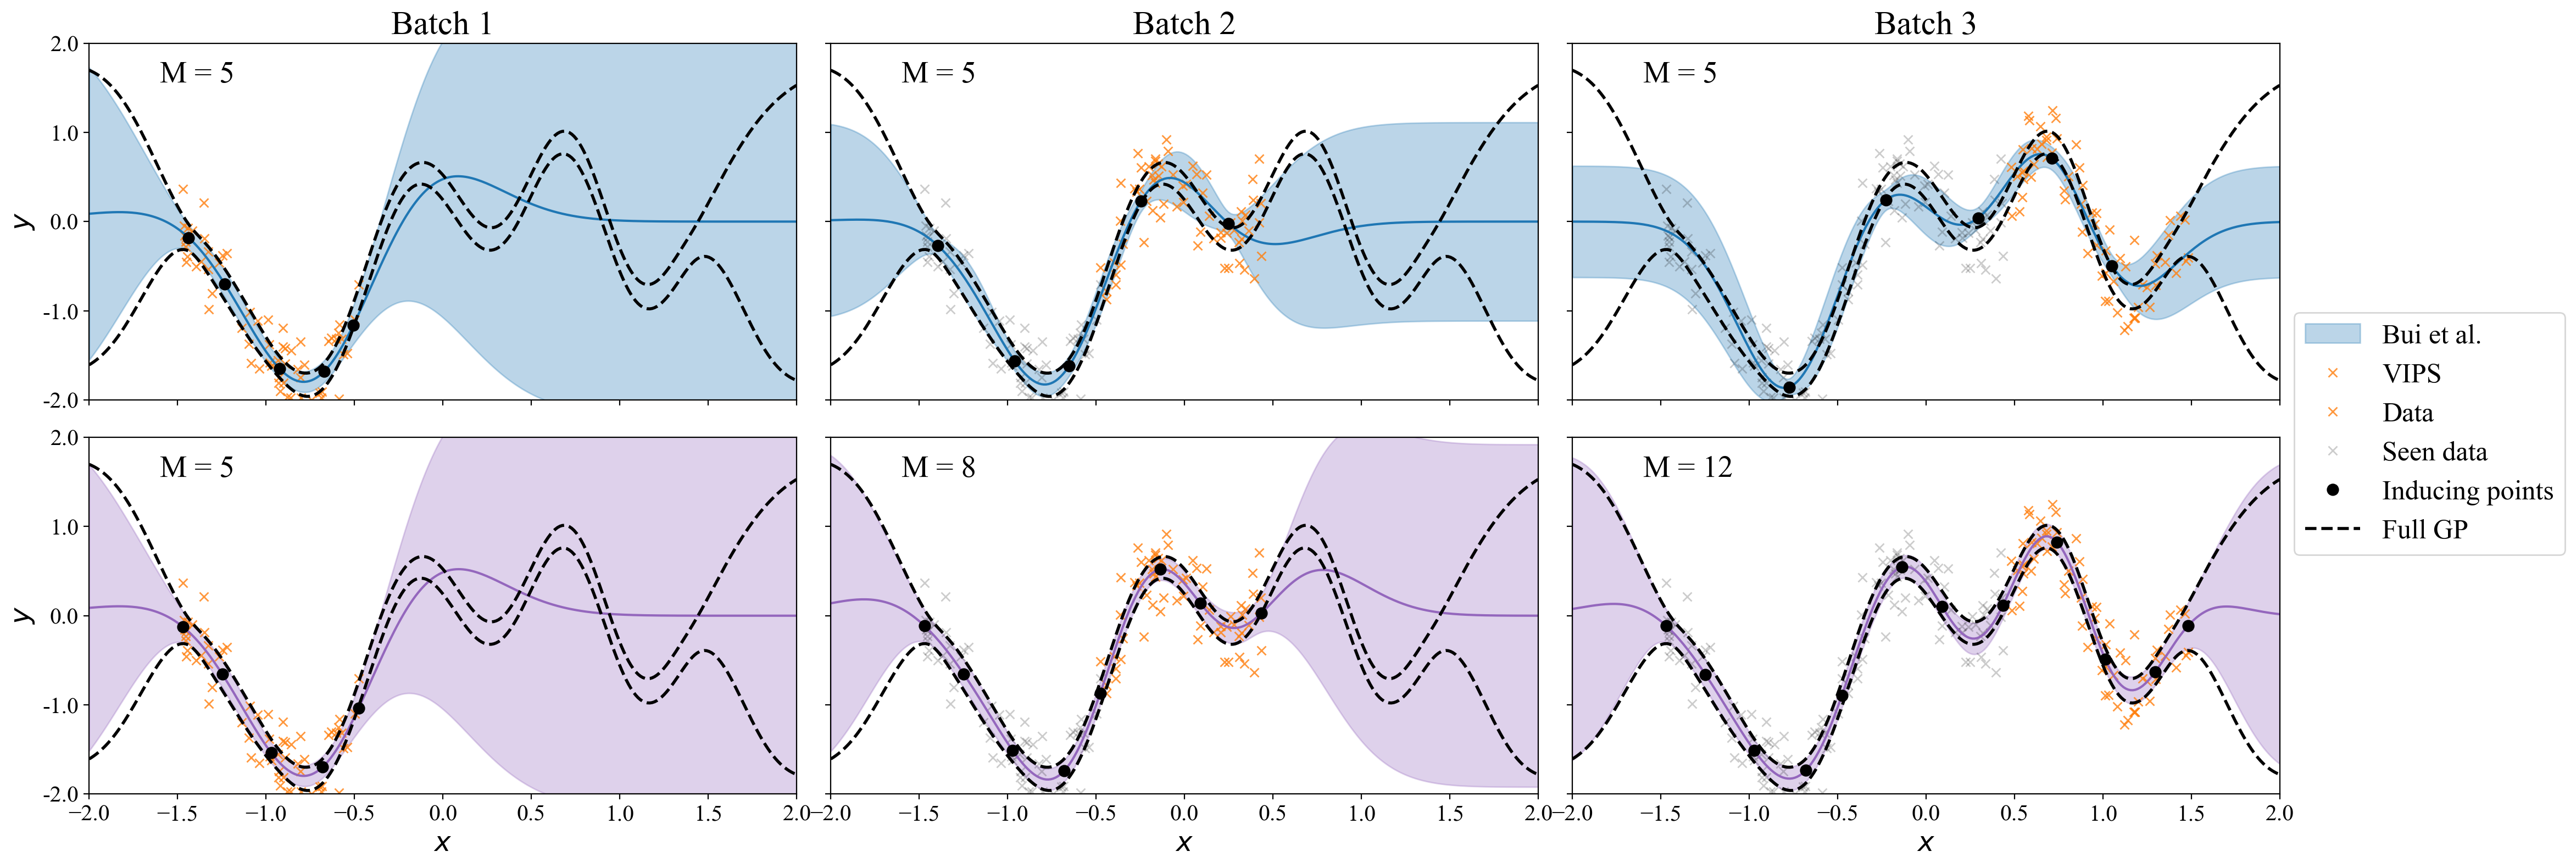

In [ ]:
fig, axs = plt.subplots(2, 3, figsize=(21, 8), sharex=True, sharey=True, dpi=200)

no_batches = 3
parameters = {'M': 5, 'eta': 1.0, 'epsilon': 0.01, 'delta': 0.01}
X_batch, y_batch = utils.div_data(X, y, no_batches)

# First row of the plot
method = 'Gradient'
j = 0
np.random.seed(0)
for i in range(no_batches):
    Xi, yi = X_batch[i], y_batch[i]
    if i == 0:
        kernel = SquaredExponential(variance=1.0, lengthscales=0.5)
        model, params = utils.init_step(Xi, yi, kernel, method, eta = parameters['eta'], epsilon = parameters['epsilon'], delta = parameters['delta'], M = parameters['M'])
        seen_x = None 
        seen_y = None
    else:
        model, params= utils.update_step(Xi, yi, SquaredExponential(lengthscales=model.kernel.lengthscales, variance=model.kernel.lengthscales), 
                                  method, mu_old, Su_old, Kaa_old, Zopt, sigma2, params, eta = parameters['eta'], epsilon = parameters['epsilon'], delta = parameters['delta'], M = parameters['M'])
        model.likelihood.variance.assign(sigma2)
        seen_x = np.vstack(X_batch[:i])
        seen_y = np.vstack(y_batch[:i])
        
    utils.run_optimization(model)
    Zopt, mu_old, Su_old, Kaa_old, sigma2 = utils.update_parameter(model)
    plot_model(model, axs[j, i], Xi, yi, xx, model_full= full_model, seen_x=seen_x, seen_y=seen_y)
    axs[j, i].set_title("Batch {}".format(i+1), fontsize=22)
    # Add the number of inducing points to inside each plot
    axs[j, i].text(0.1, 0.95, "M = {}".format(Zopt.shape[0]), transform=axs[j, i].transAxes, fontsize=20,
            verticalalignment='top')
# Second row of the plot
method = 'VIPS'
j = 1
for i in range(no_batches):
    Xi, yi = X_batch[i], y_batch[i]
    if i == 0:
        kernel = SquaredExponential(variance=1.0, lengthscales=0.5)
        model, params = utils.init_step(Xi, yi, kernel, method, eta = parameters['eta'], epsilon = parameters['epsilon'], delta = parameters['delta'], M = parameters['M'])
        seen_x = None 
        seen_y = None
    else:
        model, params = utils.update_step(Xi, yi, SquaredExponential(lengthscales=model.kernel.lengthscales, variance=model.kernel.lengthscales), 
                                  method, mu_old, Su_old, Kaa_old, Zopt, sigma2, params, eta = parameters['eta'], epsilon = parameters['epsilon'], delta = parameters['delta'], M = parameters['M'])
        model.likelihood.variance.assign(sigma2)
        seen_x = np.vstack(X_batch[:i])
        seen_y = np.vstack(y_batch[:i])
        
    utils.run_optimization(model)
    Zopt, mu_old, Su_old, Kaa_old, sigma2 = utils.update_parameter(model)
    plot_model(model, axs[j, i], Xi, yi, xx, model_full= full_model, seen_x=seen_x, seen_y=seen_y, color = 'tab:purple')
    axs[j, i].set_xlabel("$x$", fontsize=18)
    axs[j, i].text(0.1, 0.95, "M = {}".format(Zopt.shape[0]), transform=axs[j, i].transAxes, fontsize=20,
            verticalalignment='top')
# Bigger labels for y
axs[0, 0].set_ylabel("$y$", fontsize=18)
axs[1, 0].set_ylabel("$y$", fontsize=18)

# Get handles and labels for legend
handles_1, _ = axs[0, 1].get_legend_handles_labels()
handles_2, _ = axs[1, 0].get_legend_handles_labels()

# Create the legend
legend_element = [handles_1[3], 
                  handles_2[2],
                  handles_1[0], 
                  handles_1[1],
                  handles_1[4], 
                  handles_1[5]]
labels = ['Bui et al.', 'VIPS', 'Data', 'Seen data', 'Inducing points',  'Full GP']                
# Put legend on the side of the plot
fig.legend(legend_element, labels, loc='center right', fontsize=18, bbox_to_anchor=(1.12, 0.5))

plt.tight_layout()
plt.savefig("figures/motivation.pdf", dpi=500, bbox_inches='tight')